In [48]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [49]:
df = pd.read_csv("Crop land_soil moisture and input features_Dataset.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Sort (VERY IMPORTANT)
df = df.sort_values('Date')

In [50]:
df['hour'] = df['Date'].dt.hour
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek

# Drop original Date
df = df.drop(columns=['Date'])

In [51]:
target_col = 'Soil moisture plot SorgT15'

# Move target to last column
cols = [col for col in df.columns if col != target_col] + [target_col]
df = df[cols]

In [52]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(method='ffill')

/tmp/ipykernel_2476/464854712.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [53]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)

In [54]:
def create_sequences(data, seq_length=48):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length=24)

In [55]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [56]:
model = Sequential([

    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
model.compile(
    optimizer='adam',
    loss='huber'   # better than MSE for stability
)

In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0737 - val_loss: 0.0364
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0150 - val_loss: 0.0051
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0078 - val_loss: 0.0146
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - val_loss: 0.0104
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0040 - val_loss: 0.0070
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0030 - val_loss: 0.0091
Epoch 8/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0030 - val_loss: 0.0079
Epoch 9/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 0.0113
Epoch 10/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023 - val_loss: 0.0077
Epoch 11/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 12/100
251/251 ━━━━━━━━━━━━━━━━━━

In [59]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
R2 Score: 0.7477220827796072
MAE: 0.05203130483389813
RMSE: 0.06415041158963823


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.2504 - val_loss: 0.0896
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0716 - val_loss: 0.0118
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0283 - val_loss: 0.0051
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0176 - val_loss: 0.0057
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0119 - val_loss: 0.0053
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0075 - val_loss: 0.0047
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0063 - val_loss: 0.0035
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0027
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 10/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 11/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 12/150
250/250 ━━━━━━━━━━━━━━━━━━

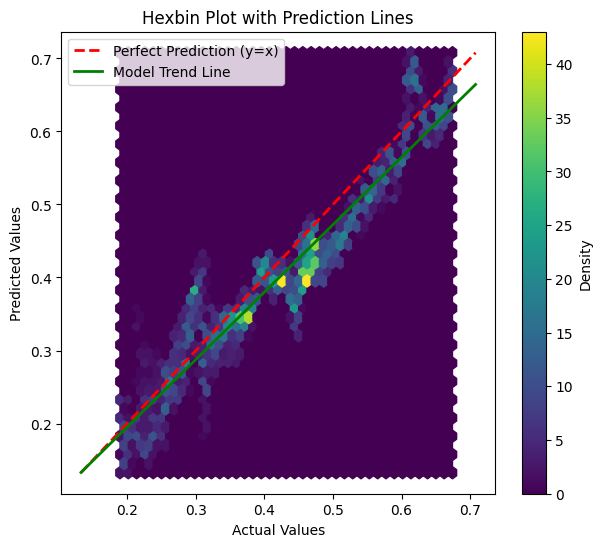

In [63]:
# ============================
# 1D CNN MODEL FOR SorgT15
# ============================

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


# ============================
# LOAD DATA
# ============================
df = pd.read_csv("Crop land_soil moisture and input features_Dataset.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')


# ============================
# FEATURE ENGINEERING
# ============================
df['hour'] = df['Date'].dt.hour
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek


# ============================
# TARGET + LAG FEATURES
# ============================
target_col = 'Soil moisture plot SorgT15'

df['lag_1'] = df[target_col].shift(1)
df['lag_2'] = df[target_col].shift(2)
df['lag_3'] = df[target_col].shift(3)

df = df.drop(columns=['Date'])


# ============================
# CLEAN DATA
# ============================
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()


# ============================
# MOVE TARGET TO LAST COLUMN
# ============================
cols = [col for col in df.columns if col != target_col] + [target_col]
df = df[cols]


# ============================
# SCALING
# ============================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)


# ============================
# CREATE SEQUENCES
# ============================
def create_sequences(data, seq_length=72):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length=72)


# ============================
# TRAIN-TEST SPLIT
# ============================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# ============================
# BUILD CNN MODEL
# ============================
model = Sequential([

    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),

    Dense(1)
])


# ============================
# COMPILE MODEL
# ============================
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='huber'
)


# ============================
# TRAIN MODEL
# ============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# ============================
# EVALUATION
# ============================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== MODEL PERFORMANCE =====")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

import matplotlib.pyplot as plt
import numpy as np

# Flatten predictions
y_pred_flat = y_pred.flatten()

# ============================
# HEXBIN PLOT
# ============================
plt.figure(figsize=(7,6))

hb = plt.hexbin(y_test, y_pred_flat, gridsize=40)
plt.colorbar(hb, label='Density')

# ============================
# PERFECT PREDICTION LINE (y = x)
# ============================
min_val = min(y_test.min(), y_pred_flat.min())
max_val = max(y_test.max(), y_pred_flat.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--', linewidth=2,
         label="Perfect Prediction (y=x)")

# ============================
# MODEL TREND LINE (BEST FIT LINE)
# ============================
# Fit regression line
m, b = np.polyfit(y_test, y_pred_flat, 1)

plt.plot([min_val, max_val],
         [m*min_val + b, m*max_val + b],
         'g-', linewidth=2,
         label="Model Trend Line")

# ============================
# LABELS
# ============================
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Hexbin Plot with Prediction Lines")

plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.2444 - val_loss: 0.0292
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0804 - val_loss: 0.0278
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0353 - val_loss: 0.0074
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0183 - val_loss: 0.0101
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0101 - val_loss: 0.0133
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0067 - val_loss: 0.0129
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0032
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0050 - val_loss: 0.0138
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039 - val_loss: 0.0073
Epoch 10/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 11/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0030 - val_loss: 0.0051
Epoch 12/150
250/250 ━━━━━━━━━━━━━━━━━━

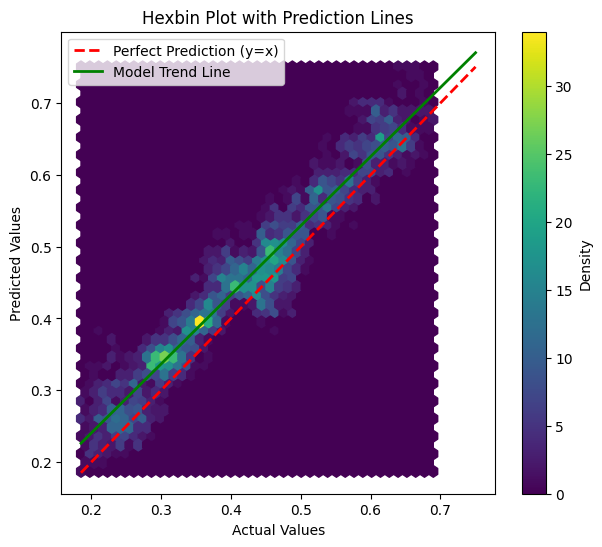

In [67]:
# ============================
# 1D CNN MODEL FOR SorgT15
# ============================

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


# ============================
# LOAD DATA
# ============================
df = pd.read_csv("Pasture land _soil moisture and input features_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')


# ============================
# FEATURE ENGINEERING
# ============================
df['hour'] = df['Date'].dt.hour
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek


# ============================
# TARGET + LAG FEATURES
# ============================
target_col = 'Soil moisture plot SorgT15'

df['lag_1'] = df[target_col].shift(1)
df['lag_2'] = df[target_col].shift(2)
df['lag_3'] = df[target_col].shift(3)

df = df.drop(columns=['Date'])


# ============================
# CLEAN DATA
# ============================
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()


# ============================
# MOVE TARGET TO LAST COLUMN
# ============================
cols = [col for col in df.columns if col != target_col] + [target_col]
df = df[cols]


# ============================
# SCALING
# ============================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)


# ============================
# CREATE SEQUENCES
# ============================
def create_sequences(data, seq_length=72):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length=72)


# ============================
# TRAIN-TEST SPLIT
# ============================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# ============================
# BUILD CNN MODEL
# ============================
model = Sequential([

    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),

    Dense(1)
])


# ============================
# COMPILE MODEL
# ============================
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='huber'
)


# ============================
# TRAIN MODEL
# ============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# ============================
# EVALUATION
# ============================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== MODEL PERFORMANCE =====")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

import matplotlib.pyplot as plt
import numpy as np

# Flatten predictions
y_pred_flat = y_pred.flatten()

# ============================
# HEXBIN PLOT
# ============================
plt.figure(figsize=(7,6))

hb = plt.hexbin(y_test, y_pred_flat, gridsize=40)
plt.colorbar(hb, label='Density')

# ============================
# PERFECT PREDICTION LINE (y = x)
# ============================
min_val = min(y_test.min(), y_pred_flat.min())
max_val = max(y_test.max(), y_pred_flat.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--', linewidth=2,
         label="Perfect Prediction (y=x)")

# ============================
# MODEL TREND LINE (BEST FIT LINE)
# ============================
# Fit regression line
m, b = np.polyfit(y_test, y_pred_flat, 1)

plt.plot([min_val, max_val],
         [m*min_val + b, m*max_val + b],
         'g-', linewidth=2,
         label="Model Trend Line")

# ============================
# LABELS
# ============================
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Hexbin Plot with Prediction Lines")

plt.legend()
plt.show()
